# 11 · The paper: "High fidelity control of a superconducting qutrit" — story, figures, numbers

Where the three years converge. The 2025 draft (`paper/story.ipynb`, `paper/plot.ipynb`, `paper/experiment_ids.ipynb`) is
kept verbatim in `docs/paper_story.md` and `docs/experiment_log_2024_2025.md`; the figures it produced are in `figures/paper_2025/`;
notebooks 02–04 and 08–09 regenerate every one of them from the raw data. This notebook is the index: the argument of the paper, the
figure gallery with what each panel shows, the headline numbers, and the one figure not covered elsewhere — where our qubit sits among
the qutrits of the literature ($E_J/E_C$).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from pulseshop import constants as C, io
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. The argument

**Context.** People want to control superconducting qutrits with high fidelity.

**Problem.** The extra computational state |2⟩ brings (1) new virtual and real (leakage) transitions inside and outside the computational
subspace, (2) qubit-style calibration methods that do not capture these new error sources, and (3) "phase advance": the two subspaces
precess at different rates, so every pulse on one subspace rotates the frame of the other.

**Method.** Amplify each error with a dedicated sequence, model it, correct it, and show the correction with the same sequence:

| error | amplifying sequence | model | correction | notebook |
|---|---|---|---|---|
| over-rotation ε | SX12 (SX12 SX12)$^N$ | heuristic $(\pi/2+\epsilon)\sigma_x + \delta\sigma_z$ vs master equation | rescale the amplitude | 04, 10 |
| phase error δ (leakage-induced) | APE: SX12 (SX12 −SX12)$^n$ −SX12(φ) | fringe shift linear in $n$ | DRAG β from DRAPE | 03, 04 |
| phase advance α, β | Ramsey with pseudo-identities on the other subspace | ideal qutrit with frame kicks | virtual Z per pulse | 07, 08 |

The story notebook's own words, with the two model fits that opened the question "ε = 3.7 % or 2.7 %?":

In [2]:
display(Markdown(open(io.REPO_ROOT / "docs" / "paper_story.md").read()))

# The paper's story (from `paper/story.ipynb`, Jan 2025)

*Verbatim notes of the author, images re-linked to this repository.*

# High fidelity control of a superconducting qutrit

## Context

People want to control superconducting qutrits with high fidelity.

## Problematic

1. The presence of another computational state, $|2\rangle$, introduces two more error sources, namely virtual and real (leakage) transitions within and out of the computational subspace.
2. Extending qubit-like calibration methods do not capture the effect introduced by the presence of new error sources.
3. Logical errors associated with different precession rates in each qutrit's subspace, resulting in non-trivial dynamical phases, called "phase advance".

## Methodology

### Characterization of error sources

To illustrate the fact that extending qubit-like calibration methods do not capture the effect introduced by the presence of new errors source, let us look at the coherent error amplifying sequence for a $\pi/2$ pulse on the (12) subspace. The sequence is described as below. The pulse used was a Gaussian pulse with amplitude calibrated by the Rabi experiment.

![](../images/sketch_rotation_error_sequence.jpg)

The sequence boosts sensitivity to over/under-rotation errors. It was not designed to detect phase errors. 

Here's the result

![](../figures/paper_2025/story_rotation_error_raw_data.png)

In this case, the error is over-rotation. $\pi/2+\epsilon$. To extract the over-rotated angle $\epsilon$, we have two methods. First, we use a master-equation-based model to extract $\epsilon$. Here's the result.

![](../figures/paper_2025/story_rotation_error_master_equation_fit.png)

From the plot, $\epsilon/(\pi/2)\approx 3.7$%. We have another model, termed "heuristic model", because it's a guess. It assumes the qutrit takes on the dynamics of a spin-1/2 particle in a oscillating external field, $H=(\frac{\pi}{2}+\epsilon)\sigma_x + \delta\sigma_z$, where $\delta$ represents the aggregate effect of phase errors. Here's the result.

![](../figures/paper_2025/story_rotation_error_two_model_fits.png)

From the plot, $\epsilon/(\pi/2)\approx 2.7$%. We **therefore** have a difference to settle.


## 2. Figure gallery (originals from `paper/plot.ipynb`)

[Fig. 0(a): Cooper-pair-box eigenstates (regenerated in notebook 10)] -> figures/paper_2025/fig0a_transmon_charge_and_phase_wavefunctions.eps (EPS, open it from the figures folder)


**Fig. 1(a): rotation-error amplification, uncorrected vs amplitude-rescaled (notebook 04)**

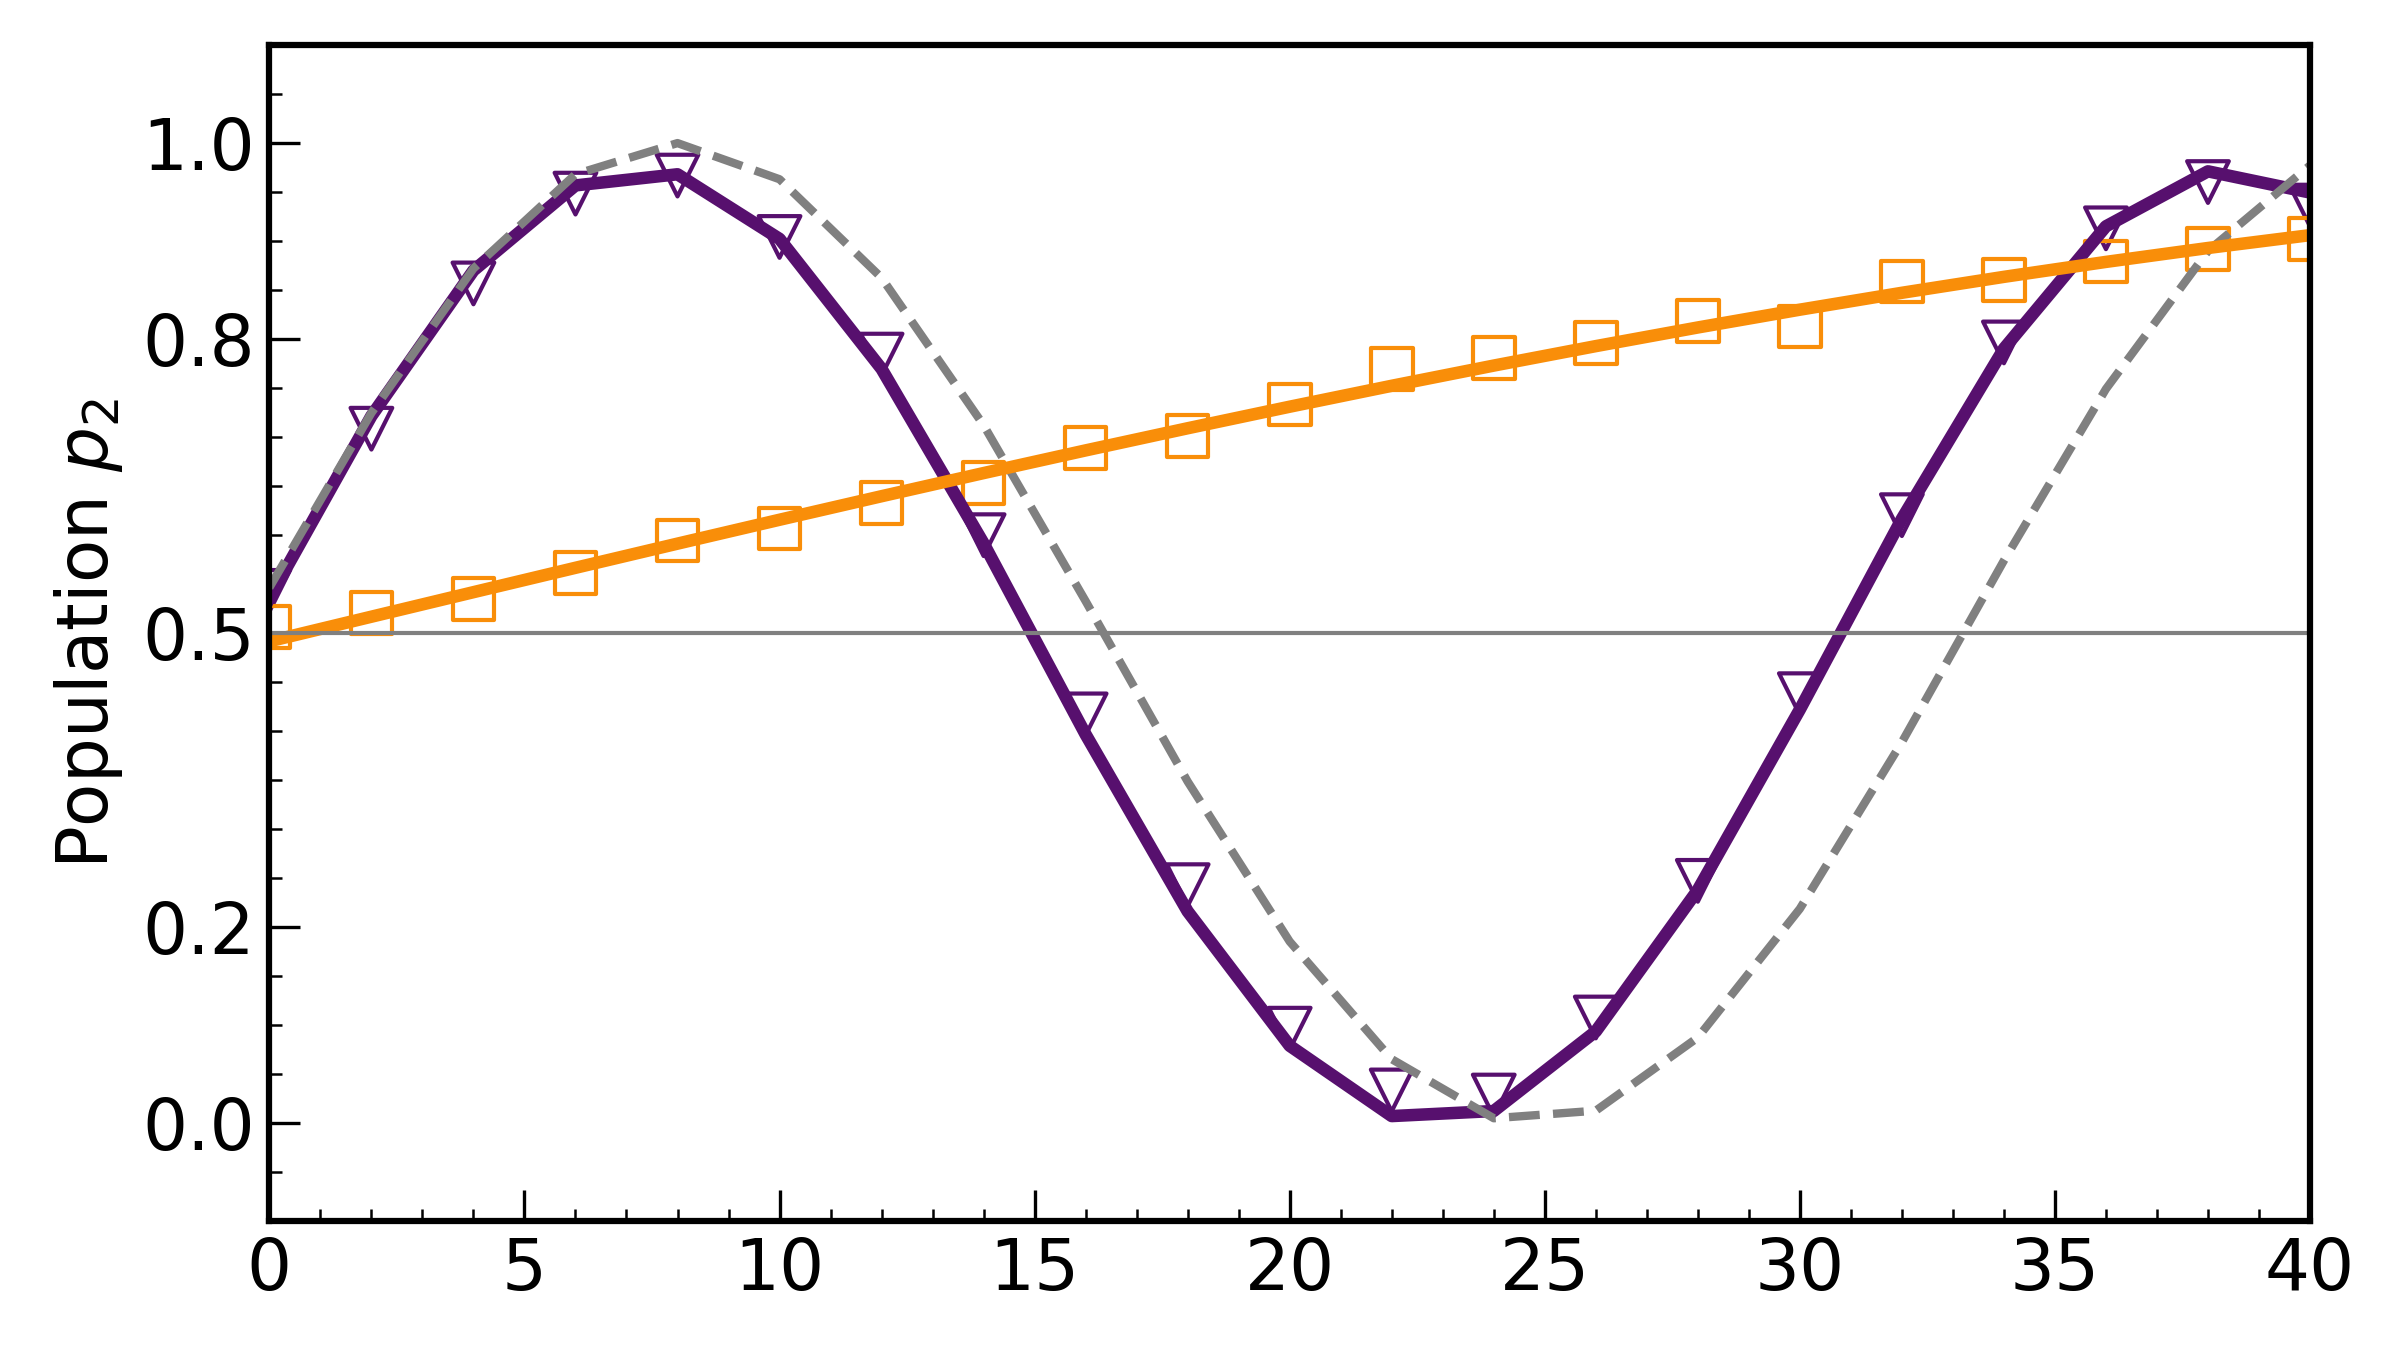

**Fig. 1(b): DRAG-Y only vs DRAG + amplitude, mean ± std of three runs (notebook 04)**

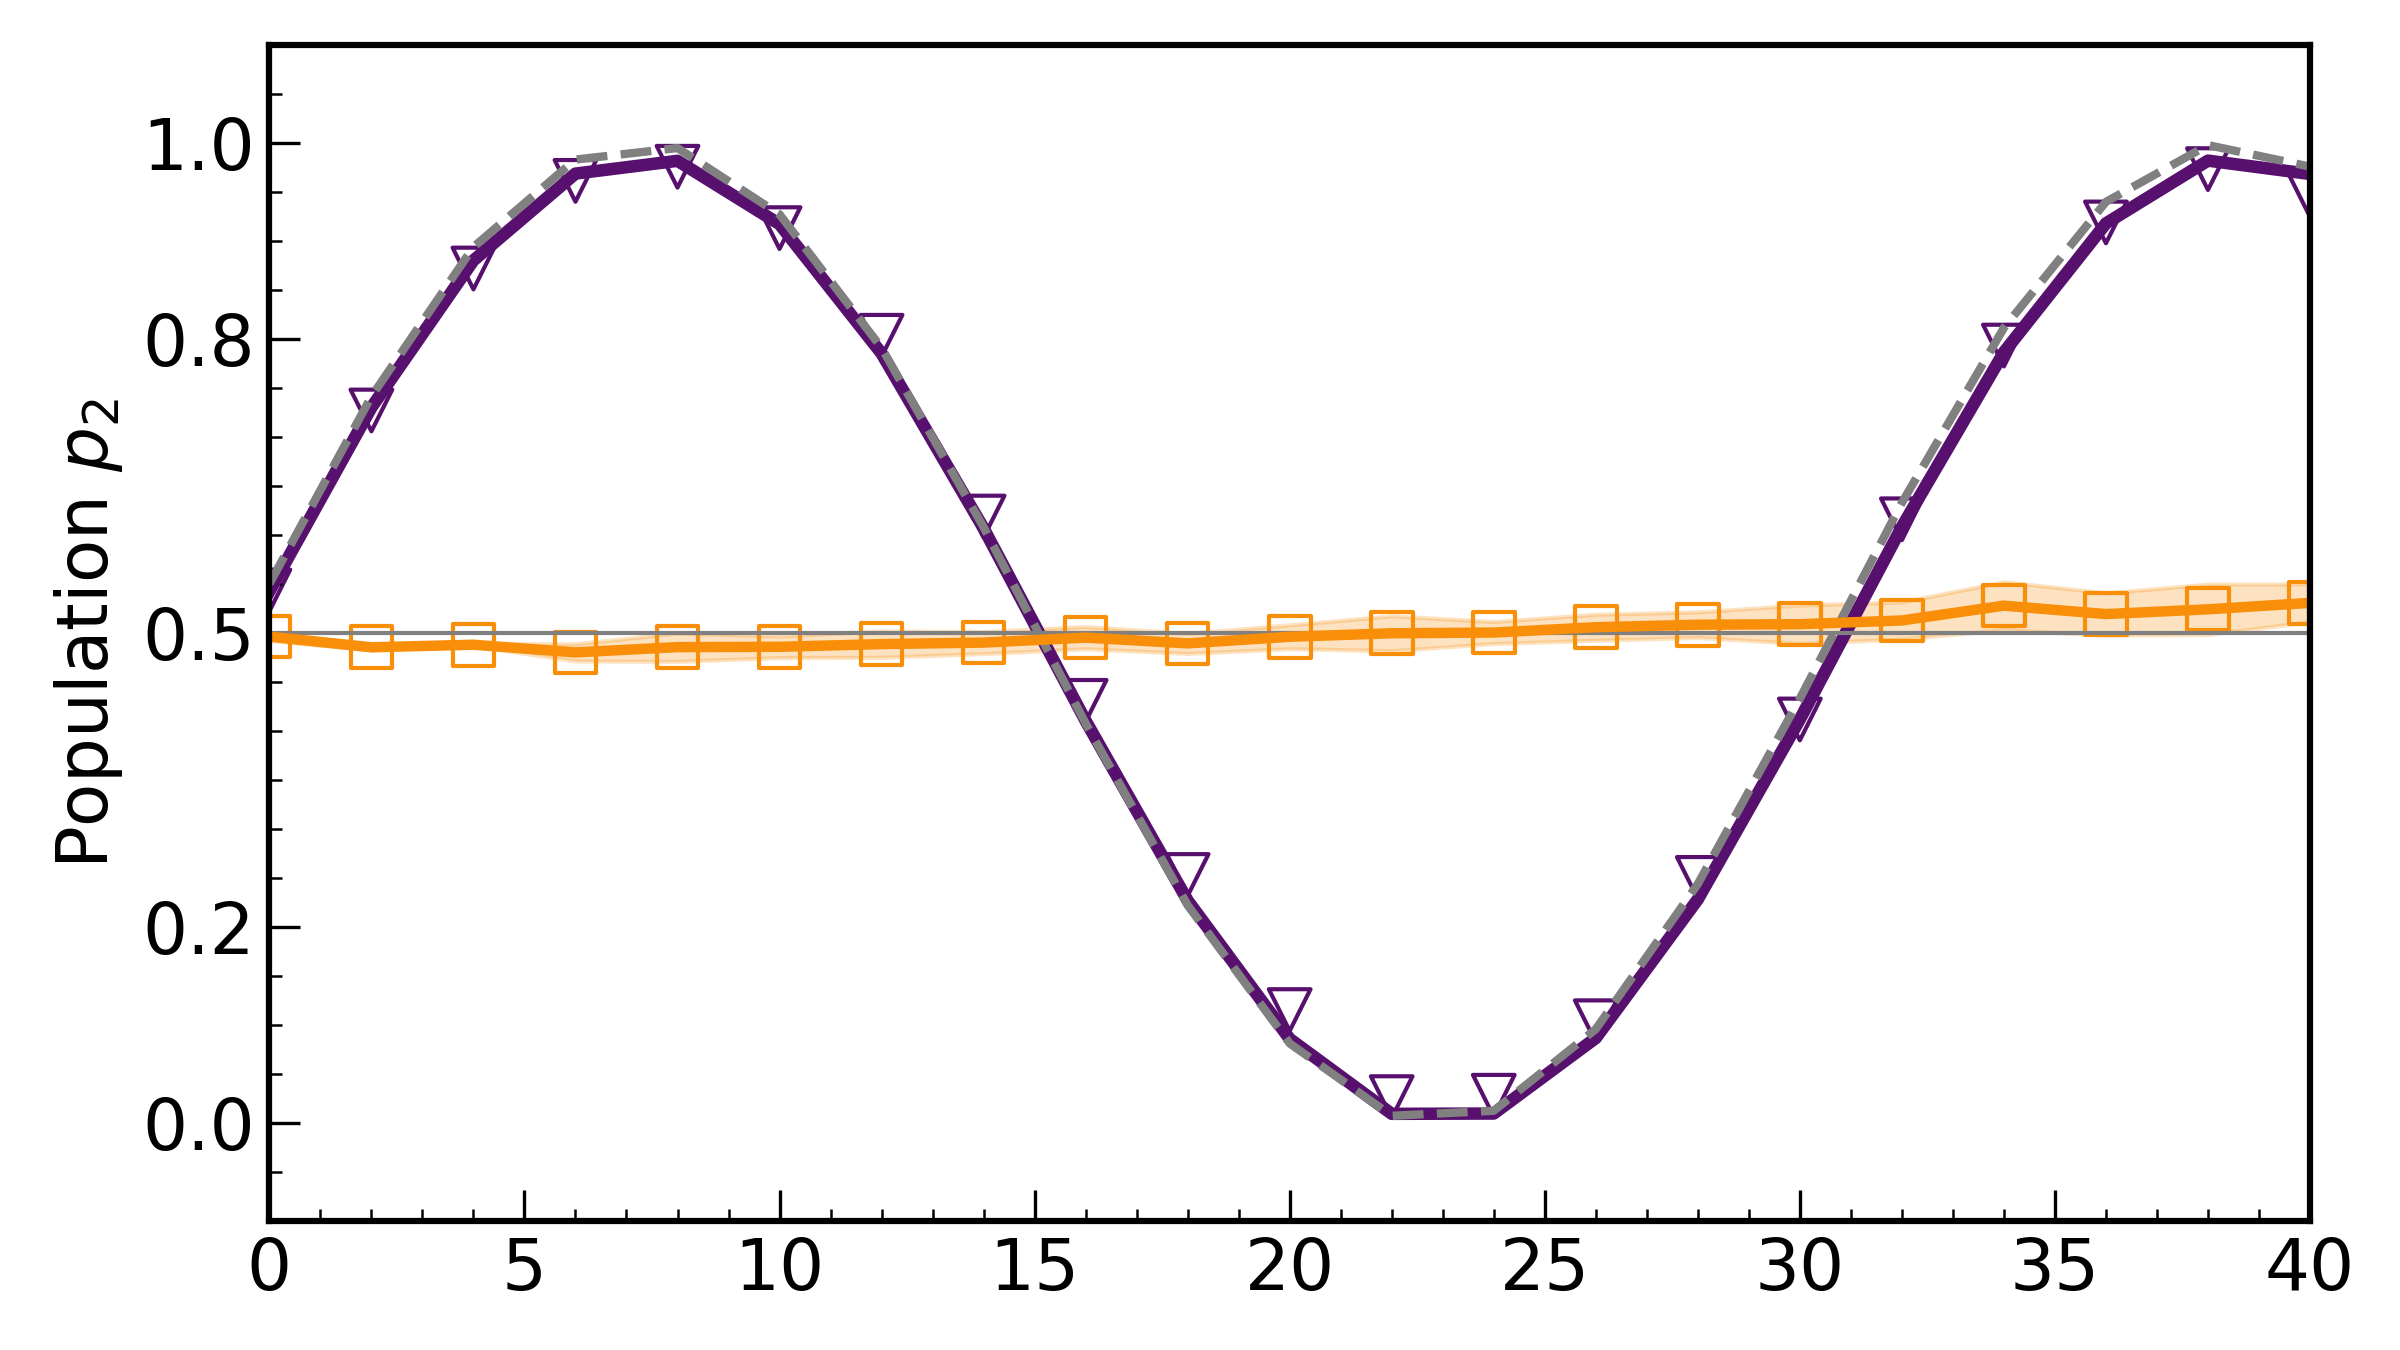

**Fig. 2(a): APE fringes before DRAG, n = 1, 3, 5, 7 (the original legend says 1-4) (notebook 04)**

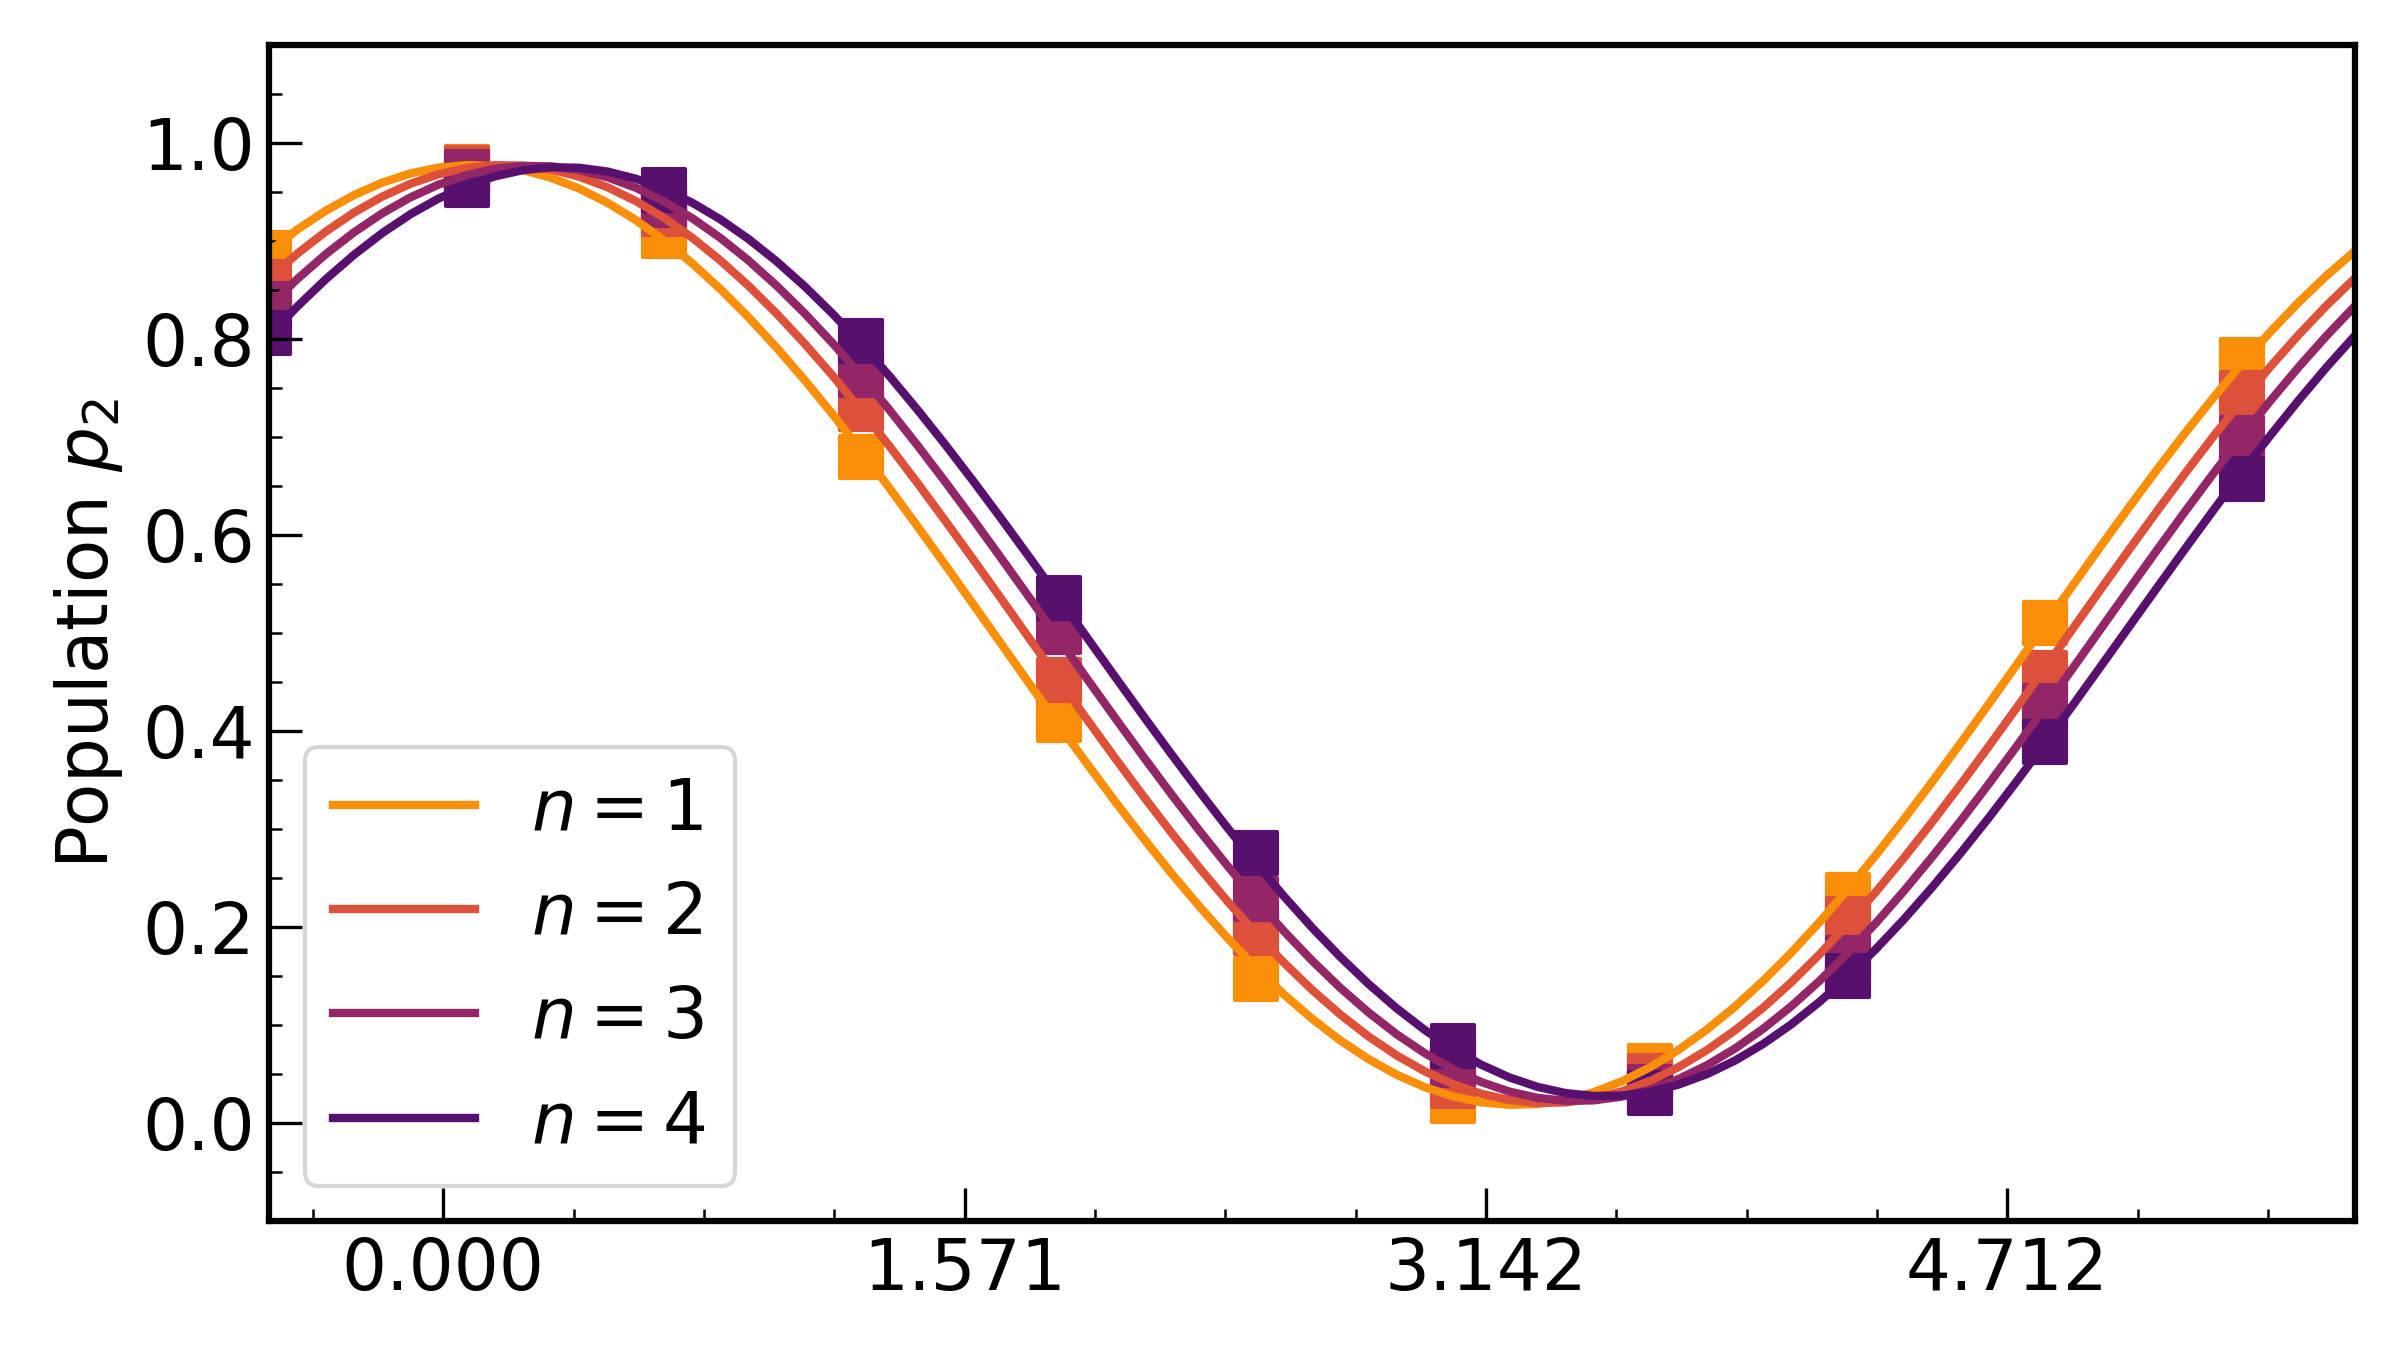

**Fig. 2(b): APE fringes after DRAG (notebook 04)**

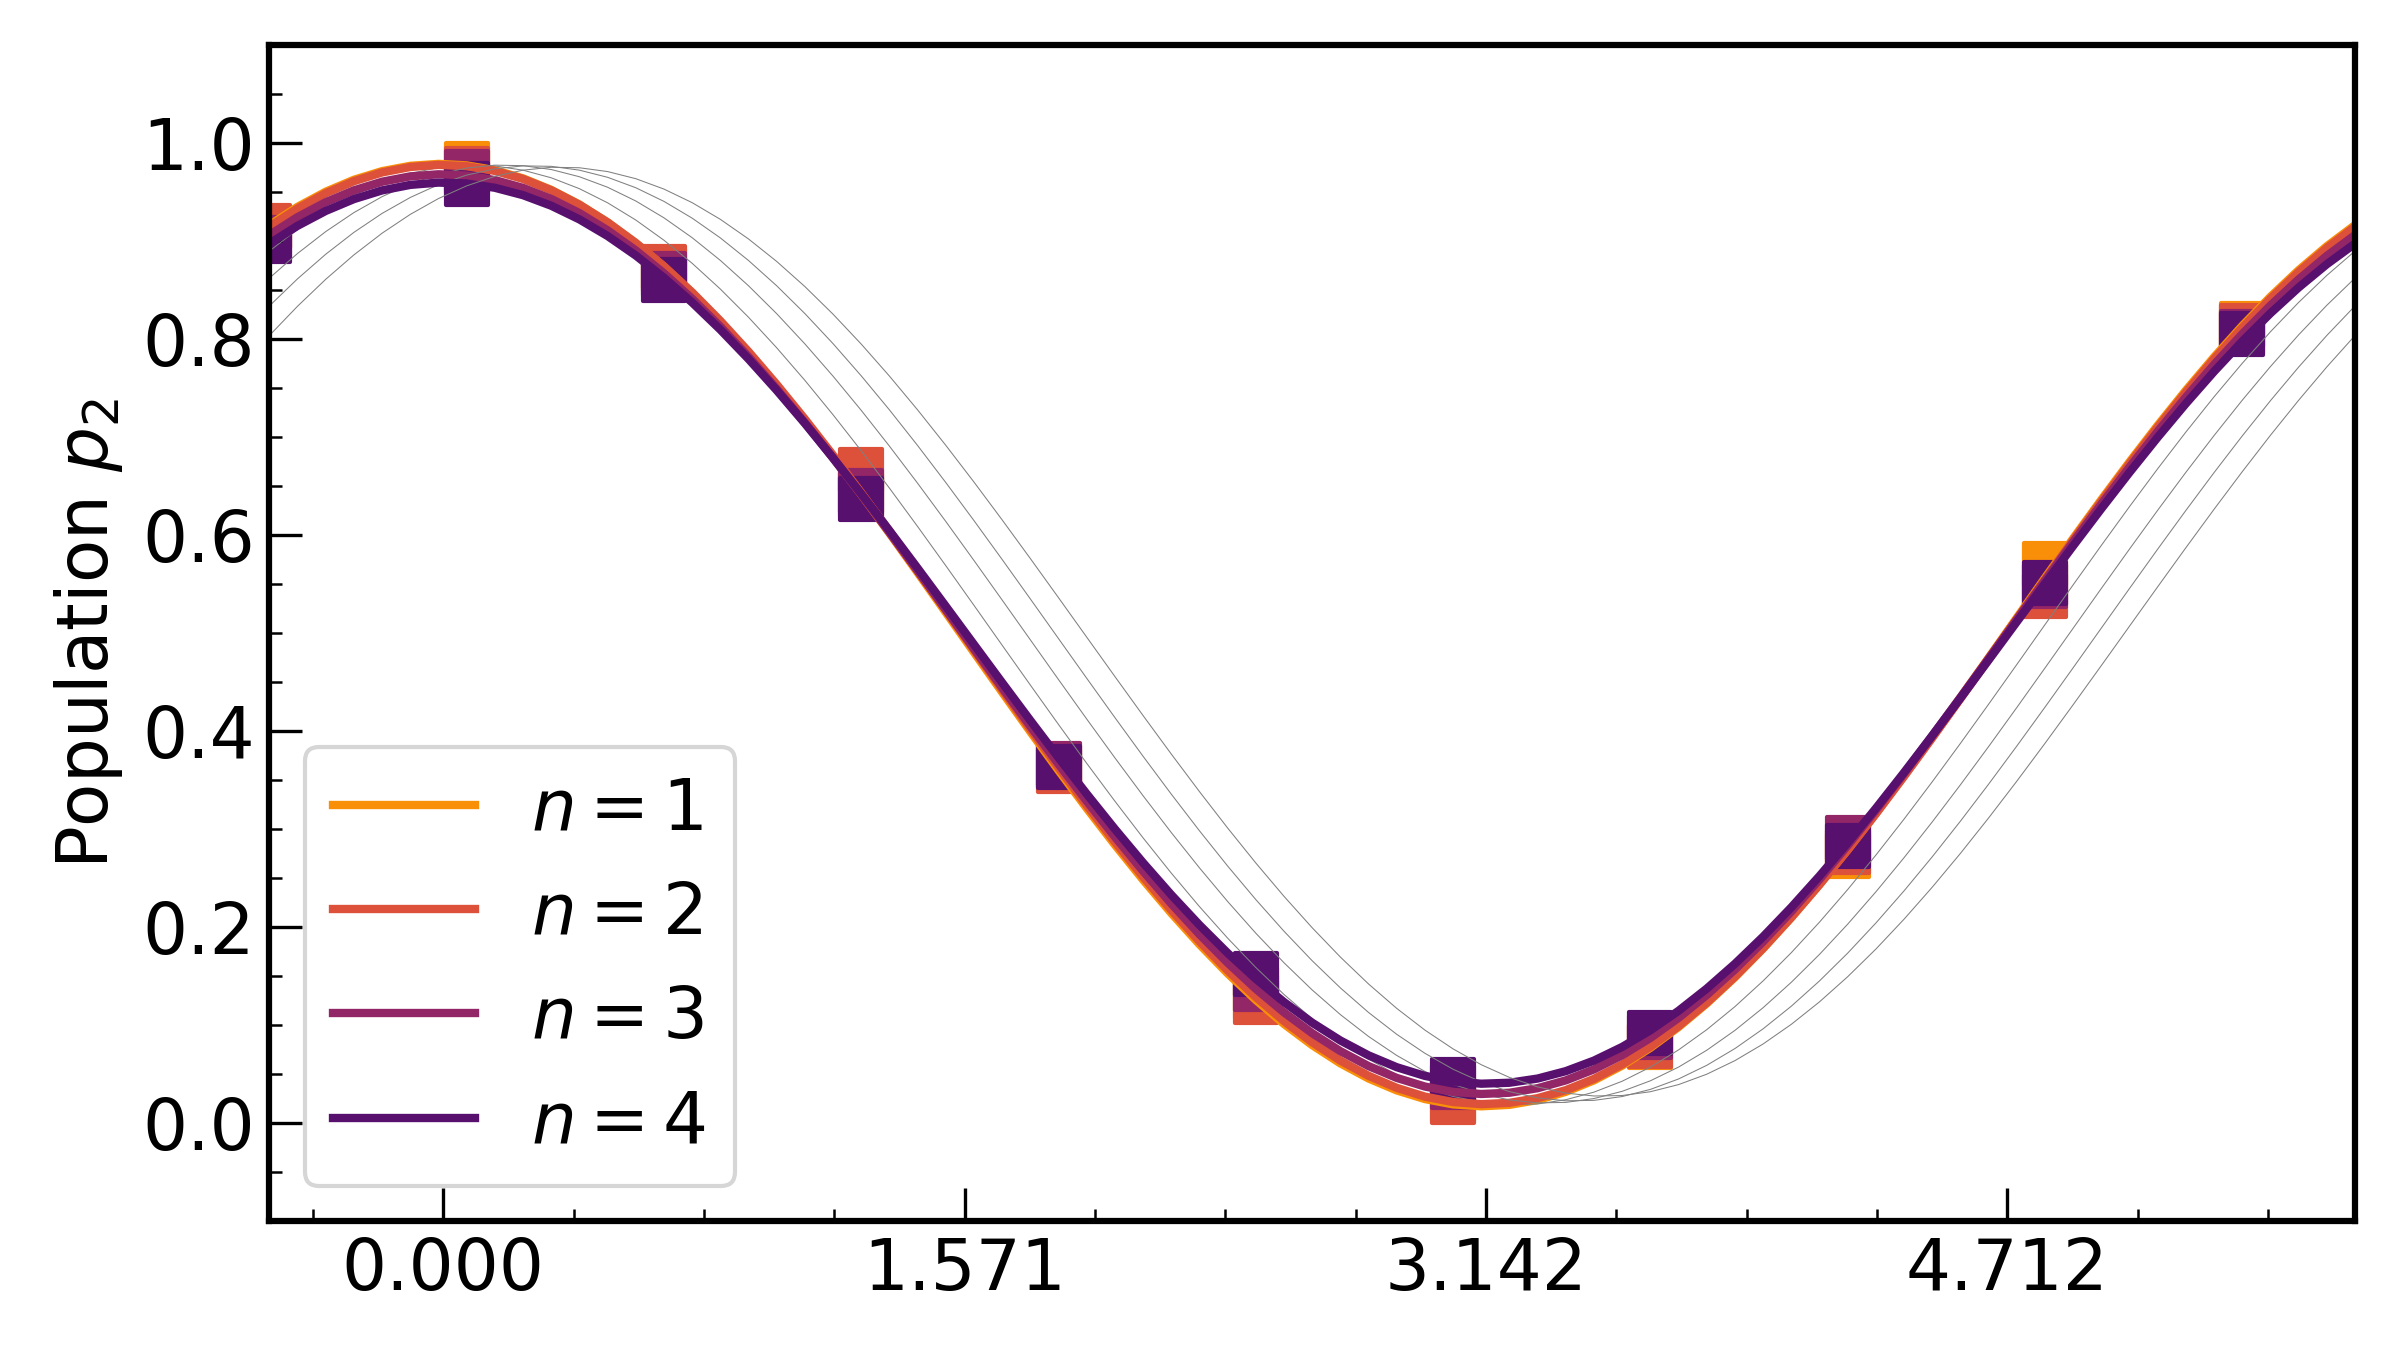

**Fig. 2 inset: phase error vs n, slopes 4.40e-2 -> 8.27e-4 (notebook 04)**

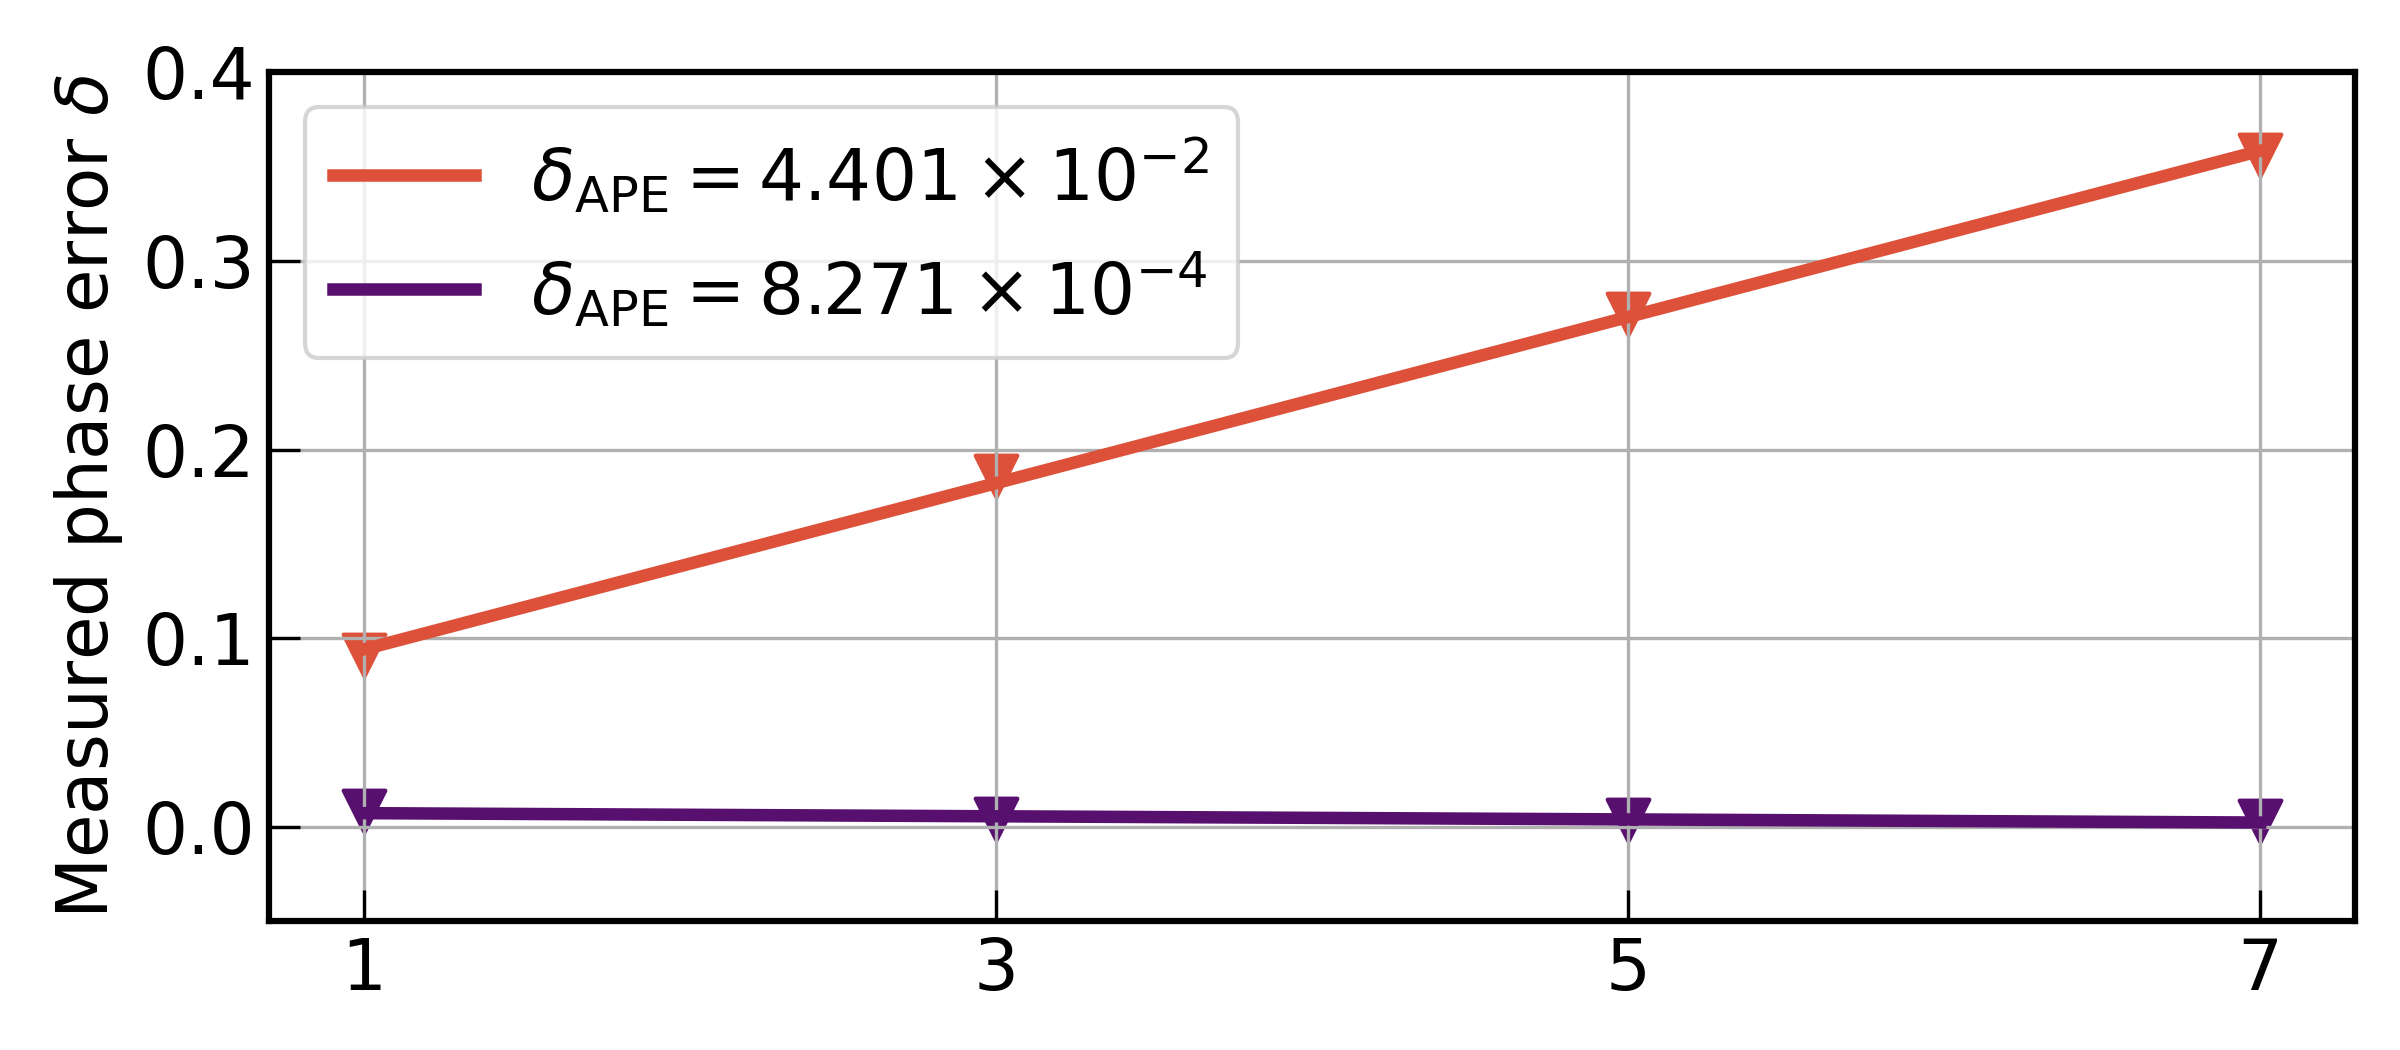

**DRAPE: P2 vs DRAG beta, lines crossing at -0.41 (notebook 03)**

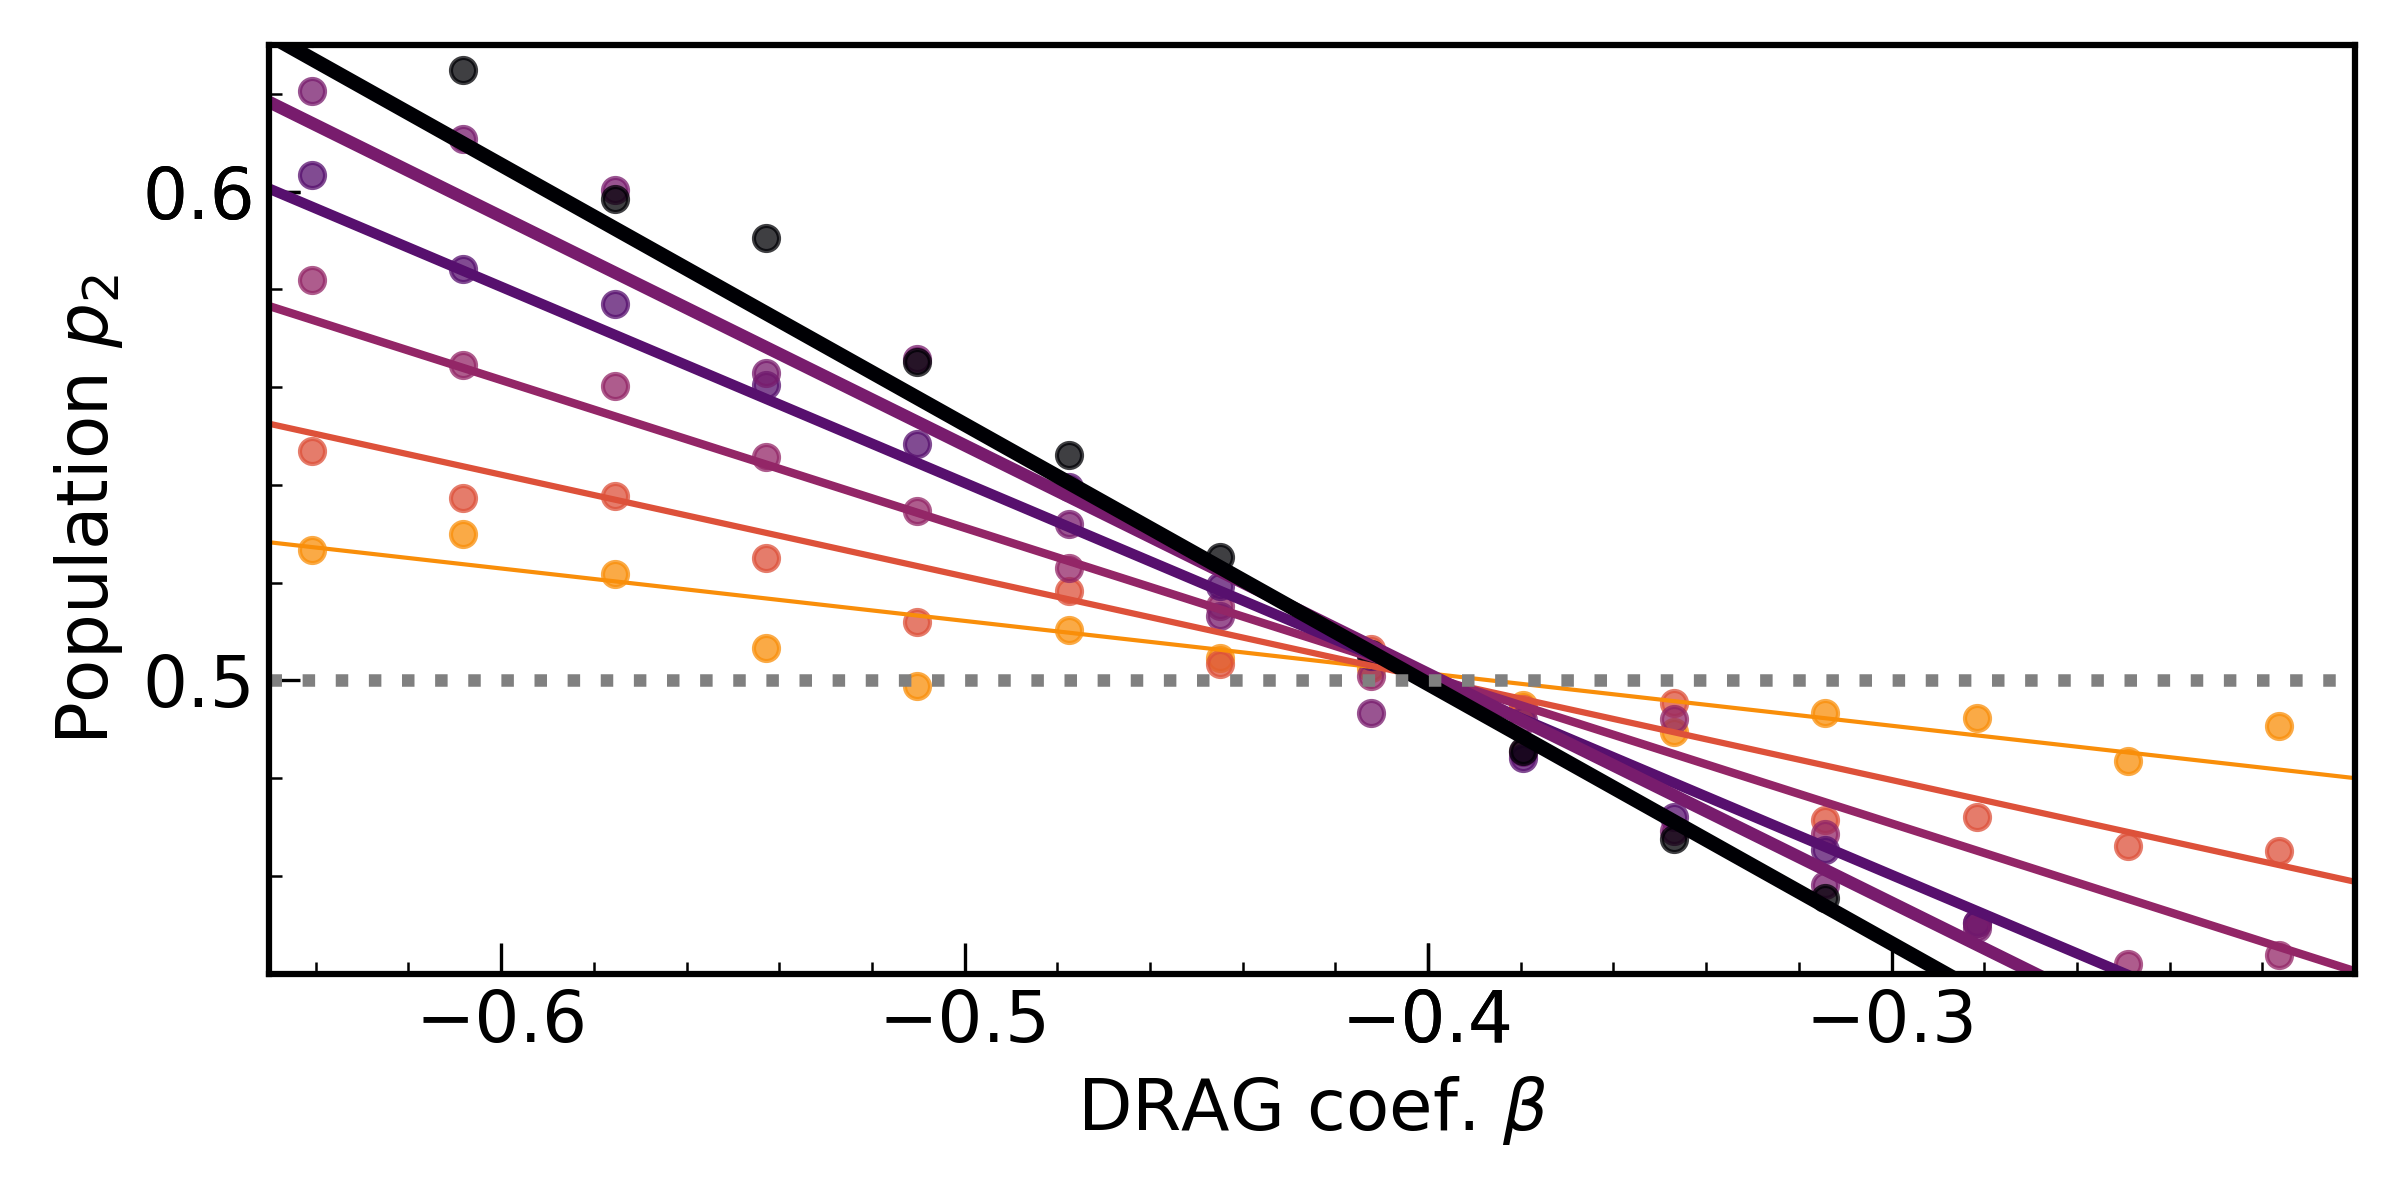

**Readout: the three IQ clusters and their nearest-centre assignment (notebook 02)**

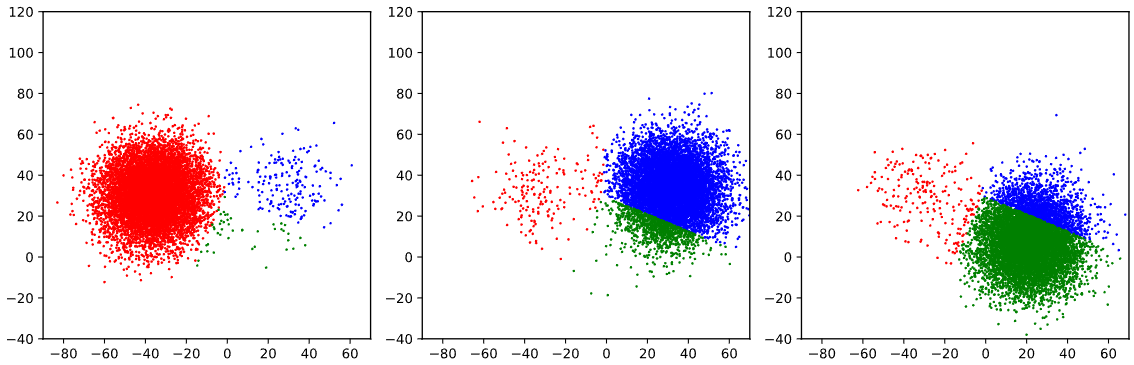

In [3]:
gallery = [
    ("paper_2025/fig0a_transmon_charge_and_phase_wavefunctions.eps", None, "Fig. 0(a): Cooper-pair-box eigenstates (regenerated in notebook 10)"),
    ("paper_2025/fig1_rotation_error_uncorrected_vs_scaled.png", 520, "Fig. 1(a): rotation-error amplification, uncorrected vs amplitude-rescaled (notebook 04)"),
    ("paper_2025/fig1_rotation_error_dragY_vs_both_corrections.png", 520, "Fig. 1(b): DRAG-Y only vs DRAG + amplitude, mean ± std of three runs (notebook 04)"),
    ("paper_2025/fig2_ape_before_correction.png", 520, "Fig. 2(a): APE fringes before DRAG, n = 1, 3, 5, 7 (the original legend says 1-4) (notebook 04)"),
    ("paper_2025/fig2_ape_after_correction.png", 520, "Fig. 2(b): APE fringes after DRAG (notebook 04)"),
    ("paper_2025/fig2_ape_inset_phase_error_vs_n.png", 420, "Fig. 2 inset: phase error vs n, slopes 4.40e-2 -> 8.27e-4 (notebook 04)"),
    ("paper_2025/drape_p2_vs_beta_linear_fits.png", 520, "DRAPE: P2 vs DRAG beta, lines crossing at -0.41 (notebook 03)"),
    ("paper_2025/discriminator_iq_clusters_q109_2025-01-31.png", 700, "Readout: the three IQ clusters and their nearest-centre assignment (notebook 02)"),
]
for f, w, cap in gallery:
    p = io.FIG_DIR / f
    if p.suffix == ".eps":
        print(f"[{cap}] -> {p.relative_to(io.REPO_ROOT)} (EPS, open it from the figures folder)")
        continue
    display(Markdown(f"**{cap}**")); display(Image(filename=str(p), width=w))

## 3. Headline numbers (as re-derived in this repository)

| quantity | value | where |
|---|---|---|
| qubit | `ibm_brisbane` 109, $f_{01}$ = 4.985 GHz, α = −307 MHz, $E_J/E_C$ ≈ 37 | 01, 11 |
| SX12 pulse | 20 ns DRAG, amp 0.2368, β = −0.414 | 01, 03 |
| over-rotation before correction | ε/(π/2) ≈ 2.6–2.7 % (heuristic), 3.7 % (master equation) | 04, 10 |
| phase error before / after DRAG | 4.4 × 10⁻² / < 10⁻³ rad per pseudo-identity | 04 |
| DRAG coefficient from DRAPE | −0.418 ± 0.005 | 03 |
| phase advance per pulse | β ≈ 0.93 rad (mod π), α ≈ 0.46 rad (mod π) for the Oct 2024 pulses; linear to n = 9 | 08 |
| readout | confusion diag 0.977 / 0.889 / 0.815 | 02 |
| $T_1$, $T_2^*$ | ≈ 80 µs (|1⟩), ≈ 150 µs (|2⟩, chain fit); $T_2^*$(1–2) ≈ 40 µs | 09 |

## 4. Where our qubit sits: $E_J/E_C$ (`figure/picasso.ipynb`, 2024)

A low $E_J/E_C$ means a large charge dispersion of the higher levels — the beating 1–2 Ramsey fringes of notebook 09 — and is the
price of IBM's fixed-frequency design compared with the qutrit-oriented devices of other groups.

ibm_brisbane q109: f01 = 4.98497 GHz, f12 = 4.67786 GHz -> E_J/E_C = 37.12


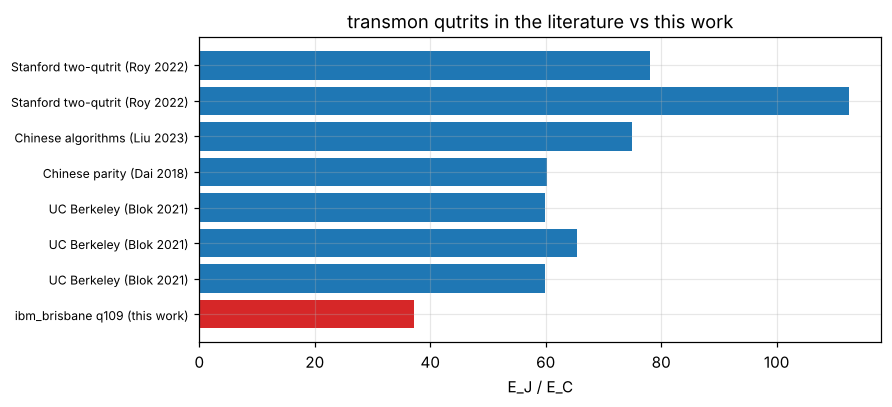

In [4]:
ours = C.ej_over_ec(4984973330.7, 4677857528.7)
print(f"ibm_brisbane q109: f01 = 4.98497 GHz, f12 = 4.67786 GHz -> E_J/E_C = {ours:.2f}")
items = []
for name, val in C.EJEC_OTHERS.items():
    vals = np.atleast_1d(val)
    for v in vals:
        items.append((name, float(v)))
fig, ax = plt.subplots(figsize=(8, 3.6))
names = [n for n, _ in items]; vals = [v for _, v in items]
colors = ["C3" if "this work" in n else "C0" for n in names]
ax.barh(range(len(items)), vals, color=colors)
ax.set_yticks(range(len(items))); ax.set_yticklabels(names, fontsize=8)
ax.set(xlabel="E_J / E_C", title="transmon qutrits in the literature vs this work")
io.save_fig(fig, "11_ej_over_ec_comparison")

## 5. Reading guide

* the *physics*, in order: 01 → 02 → 09 → 03 → 04 → 05 → 06 → 07 → 08 → 10;
* the *paper*, in order: this notebook → 04 (Fig. 1–2) → 03 (DRAPE) → 08 (phase advance) → 10 (models);
* the *history* of the shop: `docs/project_history.md`, `docs/lab_log_2024.md`, `docs/experiment_log_2024_2025.md`,
  and the original notebooks in `misc/original_notebooks/`.